<a href="https://colab.research.google.com/github/Abishek18032007/Assignment1-AIML-/blob/main/multihomeprice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("camnugent/california-housing-prices")

100%|██████████| 400k/400k [00:01<00:00, 380kB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# List the contents of the downloaded dataset directory
print(os.listdir(path))

['housing.csv']


It looks like the dataset contains `housing.csv`. Let's load this file into a pandas DataFrame and display its first few rows and information.

In [3]:
csv_file_path = os.path.join(path, 'housing.csv')
df = pd.read_csv(csv_file_path)

print("First 5 rows of the dataset:")
display(df.head())

print("\nDataset Info:")
df.info()

First 5 rows of the dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [6]:
# Impute missing values in 'total_bedrooms' with the median
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Now that missing values have been handled, let's prepare the data for machine learning. First, we'll convert the `ocean_proximity` categorical feature into numerical format using one-hot encoding.

In [7]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("First 5 rows of the dataset after one-hot encoding:")
display(df_encoded.head())

First 5 rows of the dataset after one-hot encoding:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


Now, let's split the data into features (X) and target (y), and then further divide it into training and testing sets. The target variable will be `median_house_value`.

In [8]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (16512, 12)
Shape of X_test: (4128, 12)
Shape of y_train: (16512,)
Shape of y_test: (4128,)


Finally, we will apply feature scaling to the numerical features using `StandardScaler`. This is important for many machine learning algorithms, especially those that calculate distances between data points, such as Linear Regression.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")

Features scaled successfully!


Now that the data is prepared, let's train a Linear Regression model, a Decision Tree Regressor, and a Random Forest Regressor.

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize and train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Initialize and train Decision Tree Regressor
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_scaled, y_train)

# Initialize and train Random Forest Regressor
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X_train_scaled, y_train)

print("Models trained successfully!")

Models trained successfully!


Let's evaluate the performance of each model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). Lower MSE indicates better accuracy, and a higher $R^2$ indicates a better fit of the model to the data.

In [11]:
# Evaluate Linear Regression
y_pred_lin_reg = lin_reg.predict(X_test_scaled)
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)

print(f"Linear Regression Performance:")
print(f"  Mean Squared Error (MSE): {mse_lin_reg:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lin_reg:.2f}")
print(f"  R-squared (R2): {r2_lin_reg:.2f}")

# Evaluate Decision Tree Regressor
y_pred_tree_reg = tree_reg.predict(X_test_scaled)
mse_tree_reg = mean_squared_error(y_test, y_pred_tree_reg)
rmse_tree_reg = np.sqrt(mse_tree_reg)
r2_tree_reg = r2_score(y_test, y_pred_tree_reg)

print(f"\nDecision Tree Regressor Performance:")
print(f"  Mean Squared Error (MSE): {mse_tree_reg:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_tree_reg:.2f}")
print(f"  R-squared (R2): {r2_tree_reg:.2f}")

# Evaluate Random Forest Regressor
y_pred_forest_reg = forest_reg.predict(X_test_scaled)
mse_forest_reg = mean_squared_error(y_test, y_pred_forest_reg)
rmse_forest_reg = np.sqrt(mse_forest_reg)
r2_forest_reg = r2_score(y_test, y_pred_forest_reg)

print(f"\nRandom Forest Regressor Performance:")
print(f"  Mean Squared Error (MSE): {mse_forest_reg:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_forest_reg:.2f}")
print(f"  R-squared (R2): {r2_forest_reg:.2f}")

Linear Regression Performance:
  Mean Squared Error (MSE): 4908476721.16
  Root Mean Squared Error (RMSE): 70060.52
  R-squared (R2): 0.63

Decision Tree Regressor Performance:
  Mean Squared Error (MSE): 4855424720.34
  Root Mean Squared Error (RMSE): 69680.88
  R-squared (R2): 0.63

Random Forest Regressor Performance:
  Mean Squared Error (MSE): 2401861420.45
  Root Mean Squared Error (RMSE): 49008.79
  R-squared (R2): 0.82


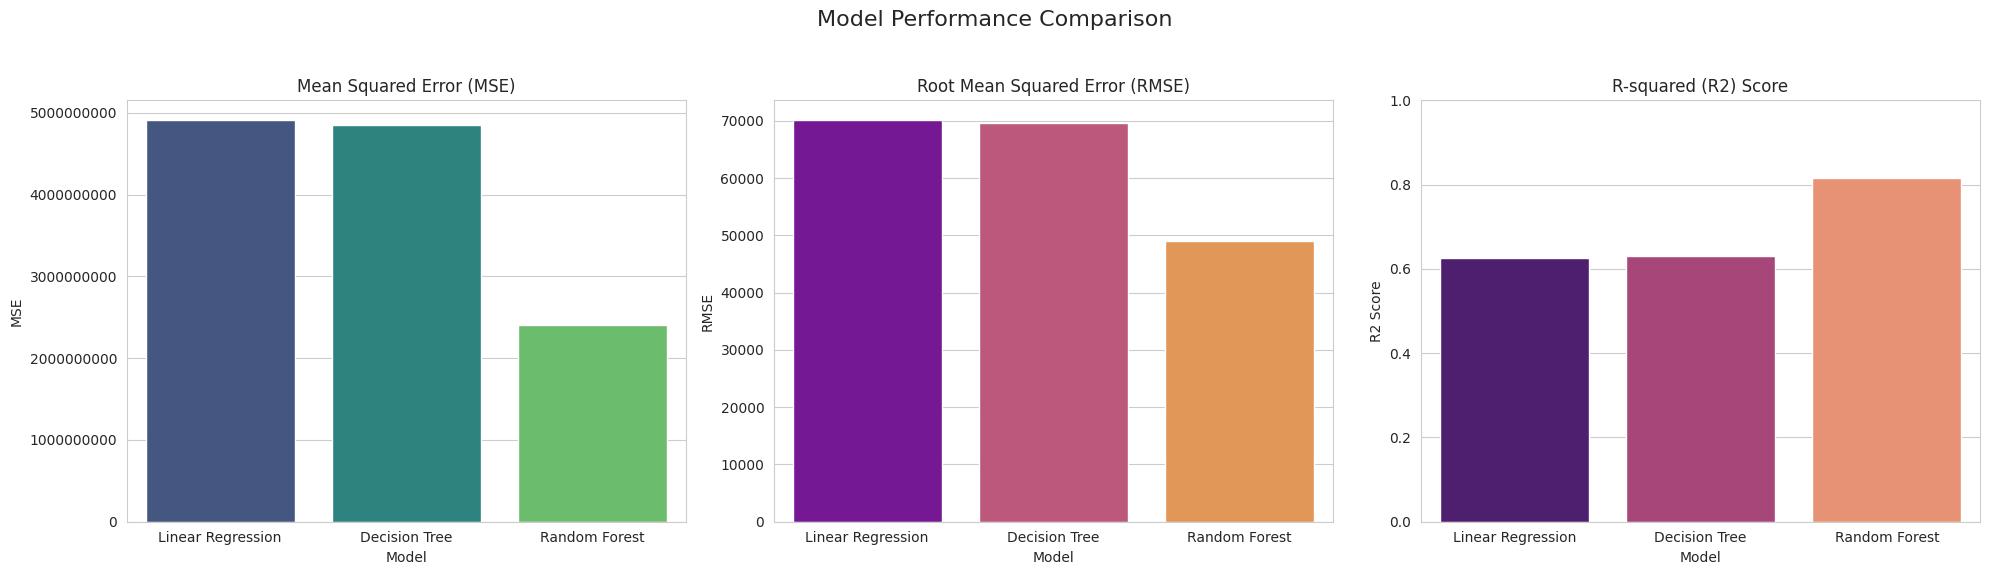

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for model performance metrics
performance_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [mse_lin_reg, mse_tree_reg, mse_forest_reg],
    'RMSE': [rmse_lin_reg, rmse_tree_reg, rmse_forest_reg],
    'R2': [r2_lin_reg, r2_tree_reg, r2_forest_reg]
}
performance_df = pd.DataFrame(performance_data)

# Set up the plot style
sns.set_style('whitegrid')

# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Plot MSE
sns.barplot(x='Model', y='MSE', hue='Model', data=performance_df, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Mean Squared Error (MSE)')
axes[0].set_ylabel('MSE')
axes[0].ticklabel_format(style='plain', axis='y')

# Plot RMSE
sns.barplot(x='Model', y='RMSE', hue='Model', data=performance_df, ax=axes[1], palette='plasma', legend=False)
axes[1].set_title('Root Mean Squared Error (RMSE)')
axes[1].set_ylabel('RMSE')
axes[1].ticklabel_format(style='plain', axis='y')

# Plot R2 Score
sns.barplot(x='Model', y='R2', hue='Model', data=performance_df, ax=axes[2], palette='magma', legend=False)
axes[2].set_title('R-squared (R2) Score')
axes[2].set_ylabel('R2 Score')
axes[2].set_ylim(0, 1) # R2 score is typically between 0 and 1

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()